## Inteligencja Obliczeniowa w Analizie Danych Cyfrowych

### Projekt 6 - problem wieloagentowy

#### Autorzy: Kacper Garwoński, Paweł Gleindek (CWL02, czwartek 11:30)

Tematem szóstego miniprojektu była analiza działania algorytmów uczenia przez wzmocnienie (ang. *reinforcement learning*) w grach wieloagentowych (tj. takich, w których występuje kilku agentów AI). Do dalszych badań wybraliśmy grę **TicTacToe** (Kółko i Krzyżyk), dostępną w bibliotece `pettingzoo`.

### Import niezbędnych bibliotek

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import torch
import gymnasium as gym
from gymnasium import spaces

from pettingzoo.classic import tictactoe_v3
from stable_baselines3 import PPO, DQN, A2C
from stable_baselines3.common.logger import configure
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

### Środowisko TicTacToe

Do eksperymentów wieloagentowych zostało wybrane klasyczne środowisko **PettingZoo Tic-Tac-Toe (`tictactoe_v3`)**.

- **Charakterystyka**: klasyczna gra w kółko i krzyżyk dla dwóch graczy. Jest to środowisko deterministyczne, o pełnej obserwowalności , o sumie zerowej (wygrana jednego to przegrana drugiego).
- **Przestrzeń akcji**: dyskretna (`Discrete(9)`), odpowiadająca 9 polom na planszy $3 \times 3$.
- **Przestrzeń obserwacji**: tablica o wymiarach $(3, 3, 2)$. Pierwsza macierz $3 \times 3$ reprezentuje pozycje znaczników gracza aktualnie wykonującego ruch, a druga – pozycje przeciwnika.
- **Nagrody**: $+1$ za wygraną, $-1$ za przegraną, $0$ za remis.

### Wrapper: TicTacToeSingleAgentWrapper

Biblioteka Stable Baselines3 (SB3) wspiera wyłącznie środowiska jednoagentowe. Ponieważ kółko i krzyżyk wymaga dwóch stron, zastosowano wrapper przekształcający grę wieloagentową w jednoagentową:

- z punktu widzenia trenowanego agenta, przeciwnik staje się częścią środowiska,
- metoda `_play_opponent_turns()` automatycznie wywołuje ruchy przeciwnika (na podstawie jego własnego modelu lub losowo), dopóki kolejka nie wróci do głównego agenta,
- wprowadzono karę (nagroda $-1$ i zakończenie gry) za próbę wykonania niedozwolonego ruchu (zgodnie z maską akcji action_mask).

Ponieważ sprowadzenie środowiska do postaci jednoagentowej wymaga oponenta, który będzie stały, proces uczenia musiał zostać zmodyfikowany. Uczenie dwóch agentów odbywa się w systemie naprzemiennych rund, gdzie jeden model aktywnie trenuje, a drugi jest zamrożony jako jego oponent, przy czym dzięki referencjom w Pythonie grający agent zawsze mierzy się z najnowszą wersją przeciwnika. Sprawia to, że środowisko staje się niestacjonarne, a na wykresach zamiast stabilnego wzrostu pojawia się charakterystyczne „falowanie” – co oznacza proces rywalizacji między dwoma modelami, gdzie każdy na przemian uczy się blokować i kontrować taktyki przeciwnika.

In [ ]:
class TicTacToeSingleAgentWrapper(gym.Env):
    def __init__(self, opponent_model=None):
        super().__init__()
        self.env = tictactoe_v3.env()
        self.observation_space = spaces.Box(low=0, high=1, shape=(3, 3, 2),
                                            dtype=np.int8)
        self.action_space = spaces.Discrete(9)
        self.opponent_model = opponent_model
        self.learning_agent = 'player_1'

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.env.reset(seed=seed)
        self.learning_agent = np.random.choice(['player_1', 'player_2'])
        self._play_opponent_turns()
        obs, _, _, _, info = self.env.last()
        return obs['observation'], info

    def step(self, action):
        obs, reward, termination, truncation, info = self.env.last()

        if termination or truncation:
            self.env.step(None)
            return obs['observation'], reward, termination, truncation, info

        valid_actions = np.where(obs['action_mask'] == 1)[0]

        if action not in valid_actions:
            return obs['observation'], -1.0, True, False, {"bad_transition": True}

        self.env.step(action)
        self._play_opponent_turns()

        obs, reward, termination, truncation, info = self.env.last()
        return obs['observation'], reward, termination, truncation, info

    def _play_opponent_turns(self):
        while self.env.agent_selection != self.learning_agent:
            obs, opp_reward, opp_term, opp_trunc, opp_info = self.env.last()
            if opp_term or opp_trunc:
                self.env.step(None)
                if not self.env.agents:
                    break
            else:
                valid_actions = np.where(obs['action_mask'] == 1)[0]
                if self.opponent_model is not None:
                    opp_action, _ = self.opponent_model.predict(obs['observation'],
                                                                deterministic=True)
                    if opp_action not in valid_actions:
                        opp_action = np.random.choice(valid_actions)
                else:
                    opp_action = np.random.choice(valid_actions)
                self.env.step(opp_action)

    def close(self):
        self.env.close()

### Funkcja `train_and_log(config, run_id)`

Odpowiada za jednoczesny, naprzemienny trening dwóch agentów w systemie ligowym/współzawodnictwa oraz rejestrację ich postępów.

**Kluczowe operacje:**

- **Obsługa Self-Play**: jeśli w konfiguracji podano tylko jednego agenta, funkcja automatycznie tworzy jego duplikat, umożliwiając algorytmowi grę z samym sobą.
- **Izolacja logów**: tworzy osobne katalogi dla każdego agenta i inicjuje wrapper `Monitor`, który zapisuje surowe statystyki (nagrody, długość epizodów) do plików `monitor.csv`.
- **Trening naprzemienny**: zamiast uczyć jeden model ciągiem, funkcja dzieli proces na mniejsze rundy (*rounds*). W każdej rundzie najpierw uczy się Agent 1 (gdy Agent 2 jest zamrożony i gra jako środowisko), a następnie Agent 2 (gdy Agent 1 jest zamrożony). Zapobiega to dominacji jednego algorytmu na wczesnym etapie.
- **Zapis**: po zakończeniu wszystkich rund zapisuje finalne wagi modeli do plików `.zip`.

In [4]:
def train_and_log(config, run_id):
    rounds = config["rounds"]
    steps_per_round = config["steps_per_round"]

    agents_cfg = list(config["agents"])
    if len(agents_cfg) == 1:
        dup = agents_cfg[0].copy()
        dup["name"] = dup["name"] + "_v2"
        agents_cfg.append(dup)

    cfg1, cfg2 = agents_cfg[0], agents_cfg[1]

    log_dir1 = f"./logs/run_{run_id}_{cfg1['name']}"
    log_dir2 = f"./logs/run_{run_id}_{cfg2['name']}"
    os.makedirs(log_dir1, exist_ok=True)
    os.makedirs(log_dir2, exist_ok=True)

    env1 = DummyVecEnv([lambda: Monitor(TicTacToeSingleAgentWrapper(opponent_model=None),
                                        log_dir1)])
    env2 = DummyVecEnv([lambda: Monitor(TicTacToeSingleAgentWrapper(opponent_model=None),
                                        log_dir2)])

    model1 = cfg1["class"]("MlpPolicy", env1, verbose=0, **cfg1["hyperparams"])
    model2 = cfg2["class"]("MlpPolicy", env2, verbose=0, **cfg2["hyperparams"])

    model1.set_logger(configure(log_dir1, ["stdout", "csv"]))
    model2.set_logger(configure(log_dir2, ["stdout", "csv"]))

    env1.envs[0].env.opponent_model = model2
    env2.envs[0].env.opponent_model = model1

    for r in range(rounds):
        model1.learn(total_timesteps=steps_per_round, reset_num_timesteps=False)
        model2.learn(total_timesteps=steps_per_round, reset_num_timesteps=False)

    path1 = f"model_run_{run_id}_{cfg1['name']}.zip"
    path2 = f"model_run_{run_id}_{cfg2['name']}.zip"
    model1.save(path1)
    model2.save(path2)

    return (log_dir1, log_dir2), (path1, path2), (cfg1, cfg2)

### Funkcja `plot_combined_learning_curves(log_dirs, configs)`

Odpowiada za wizualizację i porównanie dynamiki uczenia się wszystkich agentów biorących udział w eksperymentach.

**Kluczowe operacje:**

- **Parsowanie danych**: wyszukuje i wczytuje pliki `monitor.csv` wygenerowane przez klasę `Monitor`.
- **Wygładzanie wykresu**: surowe nagrody z kółka i krzyżyka mocno oscylują (wartości -1, 0, 1). Funkcja stosuje średnią kroczącą (ang. *moving average*) o oknie zdefiniowanym przez `window_size` w parametrach konfiguracyjnych. Dzięki temu wykres pokazuje rzeczywisty trend, a nie chaotyczne skoki.
- **Agregacja**: nakłada krzywe wszystkich agentów na jeden wspólny wykres, co pozwala na bezpośrednie porównanie np. stabilności PPO z szybkością uczenia DQN.

In [5]:
def plot_combined_learning_curves(log_dirs, configs):
    plt.figure(figsize=(10, 6))

    for log_dir, config in zip(log_dirs, configs):
        csv_path = os.path.join(log_dir, "progress.csv")
        if not os.path.exists(csv_path):
            continue

        df = pd.read_csv(csv_path)
        if "time/total_timesteps" in df.columns and "rollout/ep_rew_mean" in df.columns:
            plt.plot(df["time/total_timesteps"], df["rollout/ep_rew_mean"],
                     label=config["name"])

    plt.title("Porównanie krzywych uczenia algorytmów")
    plt.xlabel("Kroki")
    plt.ylabel("Średnia nagroda")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig("combined_learning_curves.png", dpi=300)
    plt.show()

In [6]:
def plot_smooth_learning_curves(log_dirs, window_size=50):
    plt.figure(figsize=(12, 6))

    for log_dir in log_dirs:
        monitor_path = os.path.join(log_dir, "monitor.csv")
        if not os.path.exists(monitor_path):
            continue

        df = pd.read_csv(monitor_path, skiprows=1)
        if len(df) == 0:
            continue

        smoothed_rewards = df['r'].rolling(window=window_size).mean()

        agent_name = os.path.basename(log_dir).replace("run_", "")

        plt.plot(smoothed_rewards, label=agent_name, alpha=0.8)

    plt.title("Krzywe uczenia algorytmów (Średnia nagroda - Wygładzona)")
    plt.xlabel("Liczba Epizodów")
    plt.ylabel("Nagroda na epizod (Średnia krocząca)")
    plt.legend()
    plt.grid(True)
    plt.show()

### Funkcja `evaluate_agents(model1, model2, ...)`

Walidacja końcowa polegająca na przeprowadzeniu turnieju testowego między dwoma wyuczonymi agentami.

**Kluczowe operacje:**
- **Środowisko testowe:** uruchamia czystą instancję `tictactoe_v3`.
- **Tryb deterministyczny/stochastyczny:** agenci wykonują ruchy na podstawie metody `.predict()`. W zależności od flagi `deterministic` można testować ich zachowanie optymalne lub z elementem losowości.
- **Zabezpieczenie przed błędami:** funkcja zawiera mechanizm sprawdzający maskę dozwolonych ruchów (`action_mask`). Jeśli model (np. niedouczony) wskaże zajęte pole, wrapper automatycznie podmienia jego ruch na losowy poprawny, aby dokończyć partię.
- **Metryki:** zlicza i wyświetla ostateczny bilans: Wygrane Gracza 1, Wygrane Gracza 2 oraz Remisy.

In [7]:
def evaluate_agents(model1, model2, model1_path=None, model_class1=None,
                    model2_path=None, model_class2=None, episodes=1):
    if model1 is None and model2 is None:
        try:
            model1 = model_class1.load(model1_path)
            model2 = model_class2.load(model2_path)
        except Exception as e:
            print(e)
            return

    env_eval = tictactoe_v3.env(render_mode="human")

    wins_player1 = 0
    wins_player2 = 0
    draws = 0

    for _ in range(episodes):
        env_eval.reset()

        agent_rewards = {'player_1': 0, 'player_2': 0}

        for agent in env_eval.agent_iter():
            obs, reward, termination, truncation, info = env_eval.last()

            agent_rewards[agent] = reward

            if termination or truncation:
                action = None
            else:
                valid_actions = np.where(obs['action_mask'] == 1)[0]

                if agent == 'player_1':
                    action, _ = model1.predict(obs['observation'],
                                               deterministic=False)
                else:
                    action, _ = model2.predict(obs['observation'],
                                               deterministic=False)

                if action not in valid_actions:
                    action = np.random.choice(valid_actions)

            env_eval.step(action)

        if agent_rewards['player_1'] == 1:
            wins_player1 += 1
        elif agent_rewards['player_2'] == 1:
            wins_player2 += 1
        else:
            draws += 1

    env_eval.close()

    print(f"\nWyniki starcia po {episodes} epizodach:")
    print(f"Wygrane Gracza 1 ({model1_path}): {wins_player1}")
    print(f"Wygrane Gracza 2 ({model2_path}): {wins_player2}")
    print(f"Remisy: {draws}\n")

### Charakterystyka Wykorzystanych Algorytmów

#### DQN (Deep Q-Network)

**Typ**: algorytm Off-policy, bazujący na wartościowaniu akcji (ang. *value-based*).

**Działanie:** przybliża funkcję jakości akcji $Q(s, a)$ za pomocą sieci neuronowej. Do stabilizacji procesu uczenia wykorzystuje bufor powtórek (ang. *Replay Buffer*) o rozmiarze 10 000 próbek, z którego losuje historyczne przejścia, oraz strategię $\epsilon$-zachłanną (`exploration_fraction=0.2`) do balansowania eksploracji i eksploatacji.

#### PPO (Proximal Policy Optimization)

**Typ:** algorytm on-policy, bazujący na gradiencie polityki (ang. *Policy Gradient/Actor-Critic*).

**Działanie:** optymalizuje strategię bezpośrednio, starając się jednocześnie unikać zbyt dużych, destabilizujących zmian w polityce w jednym kroku (funkcja celu z ograniczeniem clipping). Wykorzystuje współczynnik entropii (`ent_coef`), który premiuje eksplorację poprzez nagradzanie bardziej zróżnicowanych akcji.

#### A2C (Advantage Actor-Critic)

**Typ:** algorytm On-policy, hybrydowy typu Aktor-Krytyk (ang. *Actor-Critic*).

**Działanie:** algorytm ten rozdziela proces decyzyjny na dwa komponenty sieci neuronowej:

- **Aktor** (*Actor*): Odpowiada za bezpośrednią reprezentację polityki i wybiera akcje na planszy.
- **Krytyk** (*Critic*): Ocenia stany gry, prognozując oczekiwaną skumulowaną nagrodę.
- **Specyfika:** Do aktualizacji wag wykorzystuje tzw. funkcję przewagi (ang. Advantage function):
    $$A(s, a) = Q(s, a) - V(s)$$
  Funkcja ta określa, o ile lepsza jest konkretna podjęta akcja $a$ w stanie $s$ od średniej akcji w tym stanie. W przeciwieństwie do PPO, A2C dokonuje aktualizacji polityki od razu na podstawie zebranych kroków, nie posiadając mechanizmu obcinania gradientu (clipping). Sprawia to, że uczenie bywa szybsze w prostych problemach, ale jest znacznie bardziej podatne na gwałtowne załamania formy (niestabilność) w przypadku napotkania gorszej serii gier.

### Konfiguracja Eksperymentów i Hiperparametrów

Eksperyment podzielono na dwa scenariusze w celu zbadania zachowania agentów w różnych układach sił.

#### Scenariusz 1: Różne algorytmy (PPO vs DQN)

Weryfikuje, jak algorytm zorientowany na politykę (PPO) radzi sobie w bezpośrednim starciu z algorytmem zorientowanym na wartość (DQN).

**PPO Wariant 1:** standardowy współczynnik uczenia (`lr=0.0003`), mała wielkość paczki danych (`batch_size=64`), wysokie nastawienie na przyszłe nagrody (`gamma=0.99`).

**DQN:** wolniejsza nauka (`lr=0.0001`), duży bufor oraz okres eksploracji obejmujący 20% czasu trwania treningu.

#### Scenariusz 2: Te same algorytmy (PPO Self-Play)

Weryfikuje proces uczenia, w którym agent gra przeciwko samemu sobie (kopii samego siebie). Pozwala to na ciągłe podnoszenie poprzeczki, gdyż przeciwnik ewoluuje wraz z głównym agentem.

**PPO Wariant 2:** zmodyfikowane hiperparametry w stosunku do Wariantu 1. Wyższy współczynnik uczenia (`lr=0.001`), większy krok aktualizacji (`batch_size=128`), silniejsza zachęta do eksploracji (`ent_coef=0.05`) oraz krótszy horyzont planowania (`gamma=0.95`).

#### Scenariusz 3: Różne algorytmy (PPO vs A2C)

Weryfikuje, jak zaawansowany algorytm z mechanizmem ograniczenia aktualizacji polityki (PPO) radzi sobie w bezpośrednim starciu ze swoim klasycznym, synchronicznym pierwowzorem opartym na architekturze Aktor-Krytyk (A2C).

**PPO Wariant 1:** standardowy współczynnik uczenia (`lr=0.0003`), mała wielkość paczki danych (`batch_size=64`), wysokie nastawienie na przyszłe nagrody (`gamma=0.99`).

**A2C:** wyższy współczynnik uczenia (`lr=0.0007`), wysokie nastawienie na przyszłe nagrody (`gamma=0.99`) oraz brak mechanizmu obcinania gradientu (clipping), co skutkuje natychmiastową i bardziej agresywną aktualizacją wag sieci po zebraniu danych.

In [8]:
setups = [
        {
            "name": "PPO_vs_DQN",
            "rounds": 85,
            "steps_per_round": 2050,
            "agents": (
                {
                    "name": "PPO_Wariant_1",
                    "class": PPO,
                    "hyperparams": {
                        "learning_rate": 0.0003,
                        "gamma": 0.99,
                        "ent_coef": 0.01,
                        "batch_size": 64
                    }
                },
                {
                    "name": "DQN",
                    "class": DQN,
                    "hyperparams": {
                        "learning_rate": 0.0001,
                        "gamma": 0.99,
                        "exploration_fraction": 0.2,
                        "buffer_size": 10000
                    }
                }
            )
        },
        {
            "name": "PPO_SelfPlay",
            "rounds": 85,
            "steps_per_round": 2050,
            "agents": (
                {
                    "name": "PPO_Wariant_2",
                    "class": PPO,
                    "hyperparams": {
                        "learning_rate": 0.001,
                        "gamma": 0.95,
                        "ent_coef": 0.05,
                        "batch_size": 128
                    }
                },
            )
        },
        {
            "name": "PPO_vs_A2C",
            "rounds": 40,
            "steps_per_round": 1000,
            "agents": (
                {
                    "name": "PPO_Wariant_1",
                    "class": PPO,
                    "hyperparams": {
                        "learning_rate": 0.0003,
                        "gamma": 0.99,
                        "ent_coef": 0.01,
                        "batch_size": 64
                    }
                },
                {
                    "name": "A2C",
                    "class": A2C,
                    "hyperparams": {
                        "learning_rate": 0.0007,
                        "gamma": 0.99,
                        "ent_coef": 0.01,
                        "gae_lambda": 1.0
                    }
                }
            )
        }
    ]

### Metodologia Ewaluacji i Monitorowania

**Krzywe uczenia:** wrapper `Monitor` zapisuje nagrody z każdego epizodu do plików CSV. Na ich podstawie funkcja `plot_learning_curves` generuje wykresy średniej kroczącej nagród (okno wygładzania `window_size=200`). Pozwala to ocenić stabilność i prędkość zbieżności algorytmów.

**Ewaluacja końcowa:** po zakończeniu sesji treningowych, zamrożone modele rozgrywają między sobą 10 testowych epizodów (bez aktualizacji wag). Wynik końcowy (liczba wygranych gracza 1, gracza 2 oraz remisów) stanowi ostateczną miarę skuteczności wyuczonej strategii.

In [3]:
all_log_dirs = []
all_agent_configs = []
saved_runs = []

for i, config in enumerate(setups):
    log_dirs, paths, final_configs = train_and_log(config, i)

    all_log_dirs.extend(log_dirs)
    all_agent_configs.extend(final_configs)

    saved_runs.append({
        "paths": paths,
        "classes": (final_configs[0]["class"], final_configs[1]["class"])
    })

### Krzywe uczenia PPO vs DQN

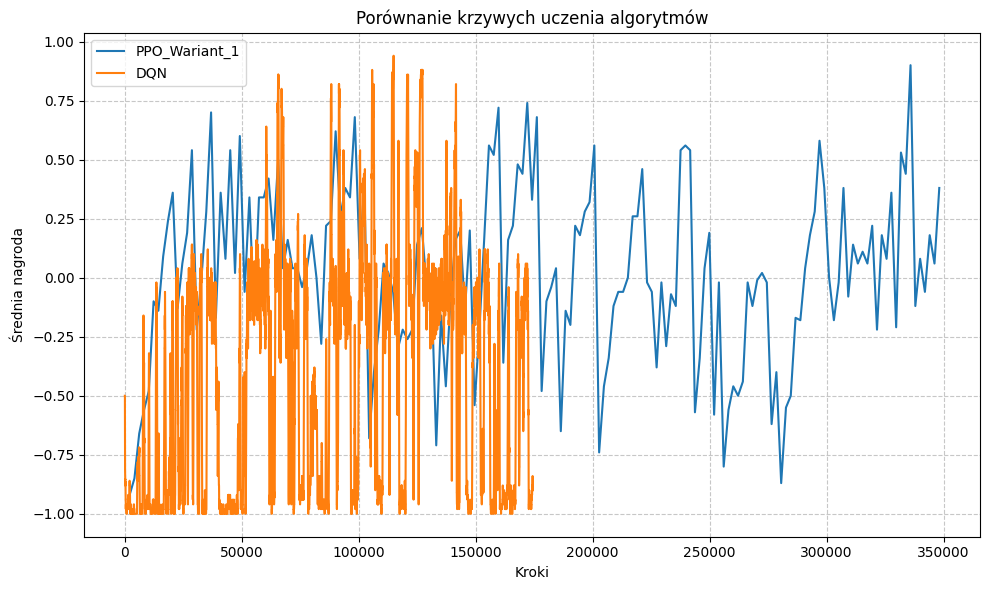

In [10]:
plot_combined_learning_curves(all_log_dirs[0:2], all_agent_configs[0:2])

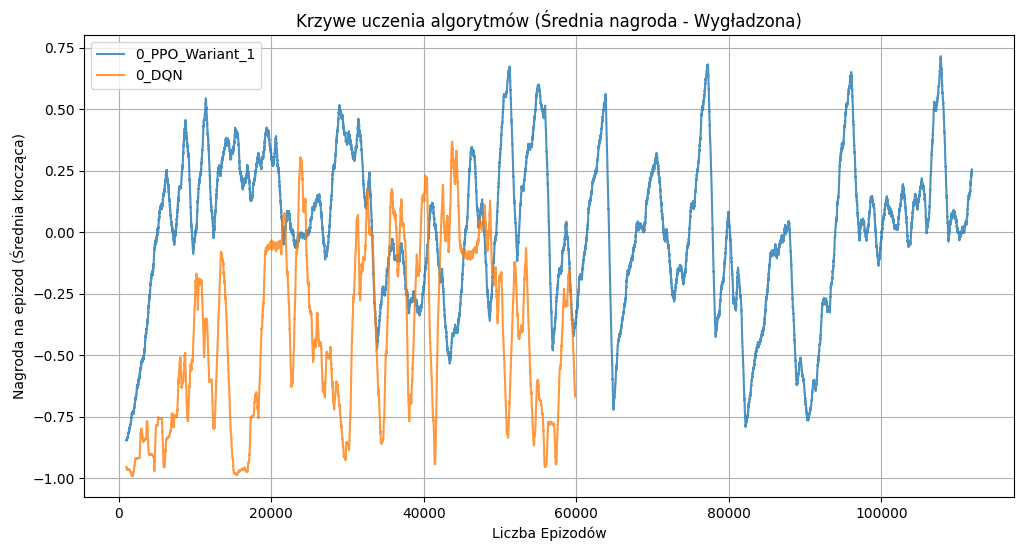

In [15]:
plot_smooth_learning_curves(all_log_dirs[0:2], 1000)

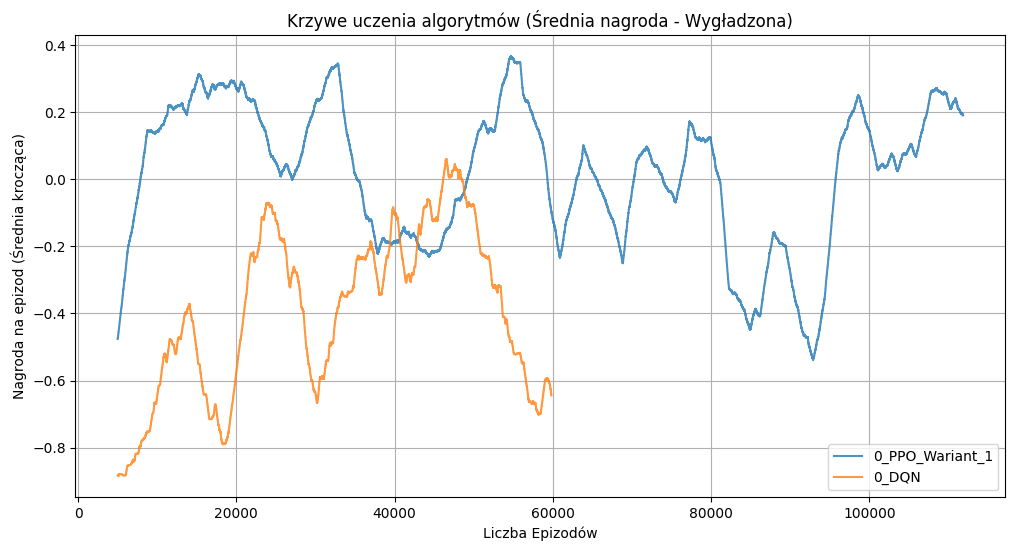

In [16]:
plot_smooth_learning_curves(all_log_dirs[0:2], 5000)

### Krzywe uczenia PPO1 vs PPO2

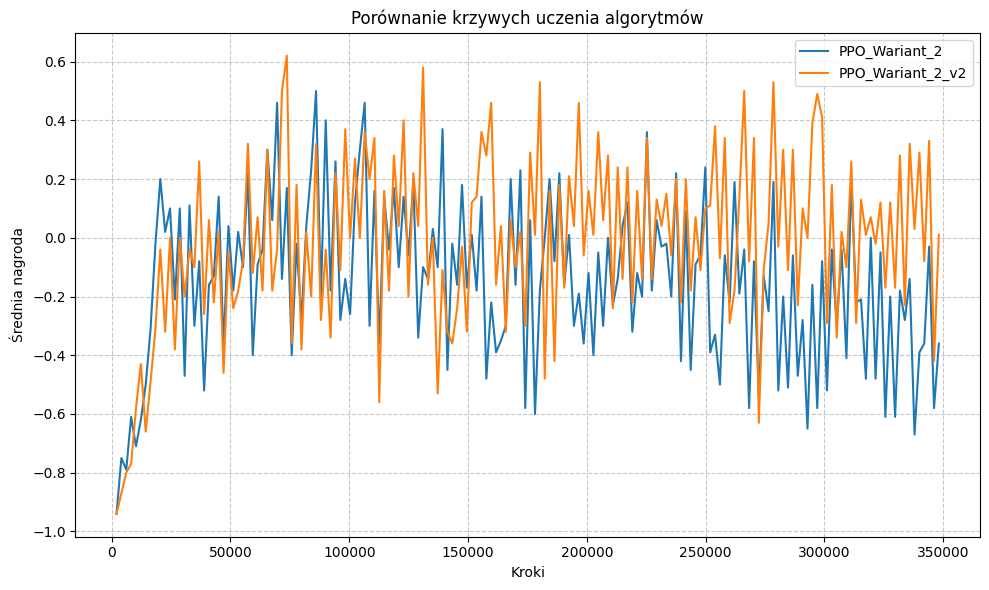

In [17]:
plot_combined_learning_curves(all_log_dirs[2:4], all_agent_configs[2:4])

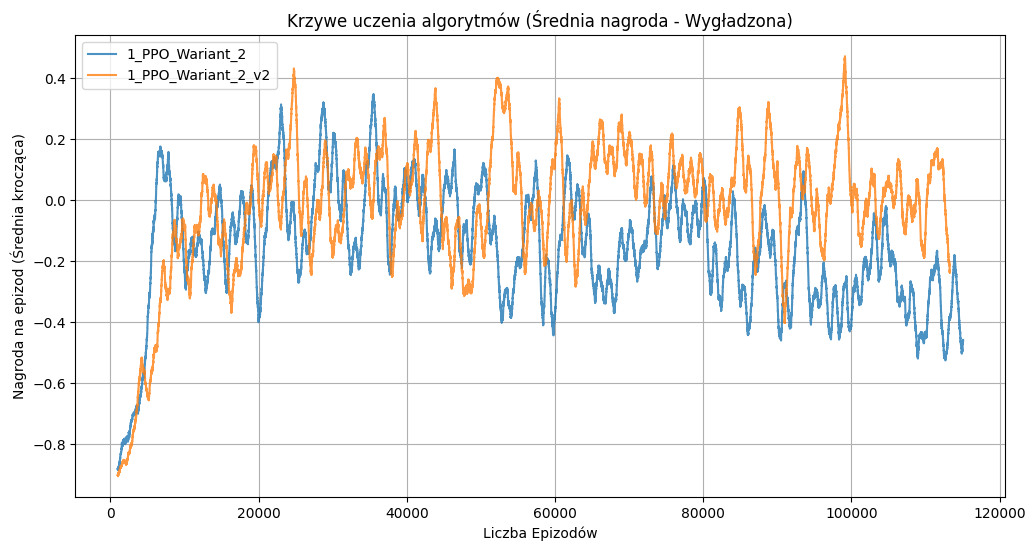

In [18]:
plot_smooth_learning_curves(all_log_dirs[2:4], 1000)

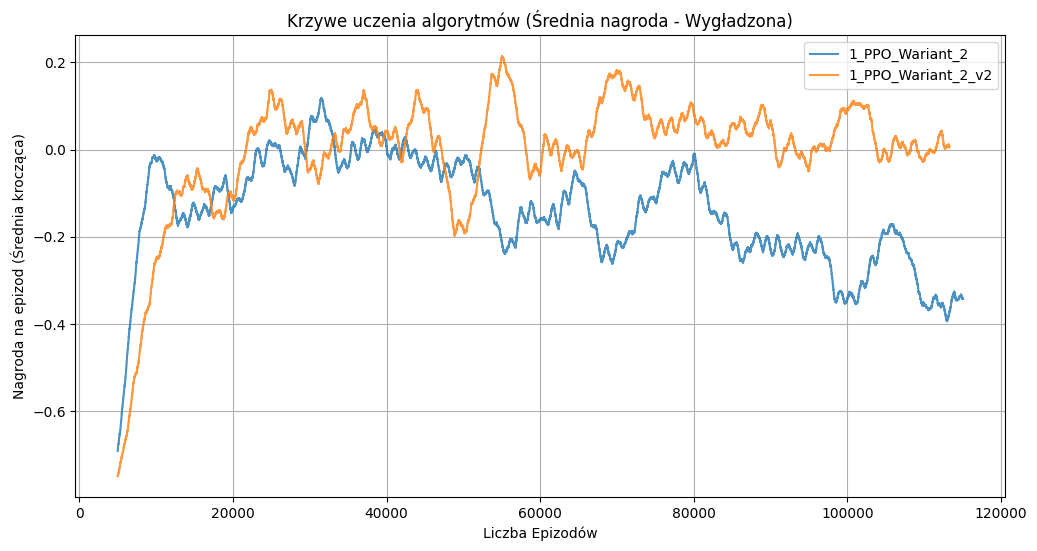

In [19]:
plot_smooth_learning_curves(all_log_dirs[2:4], 5000)

### Krzywe uczenia PPO vs ACG

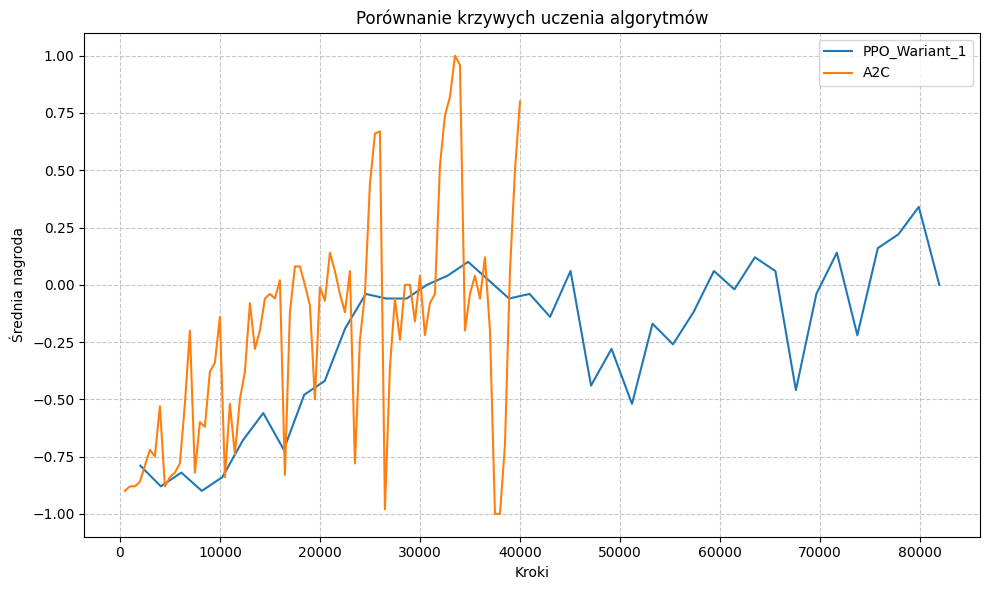

In [20]:
plot_combined_learning_curves(all_log_dirs[4:6], all_agent_configs[4:6])

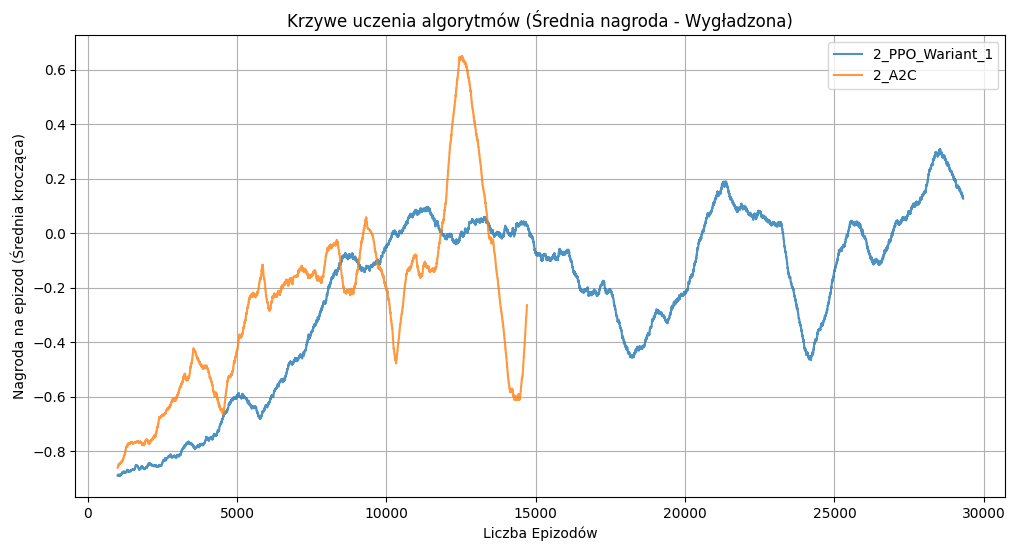

In [21]:
plot_smooth_learning_curves(all_log_dirs[4:6], 1000)

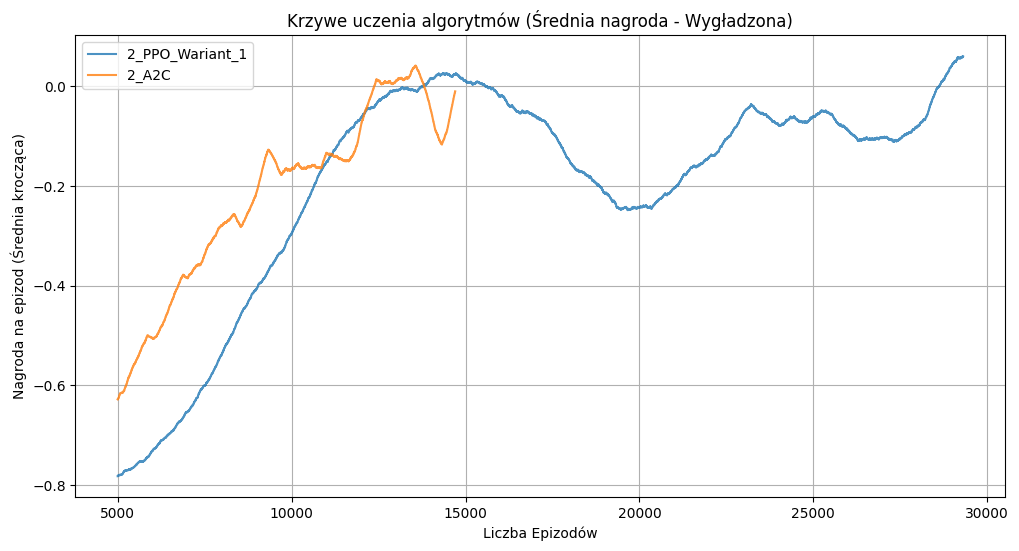

In [22]:
plot_smooth_learning_curves(all_log_dirs[4:6], 5000)

### Ewaluacja działania agentów

In [ ]:
if hasattr(torch, 'serialization') and hasattr(torch.serialization, 'load'):
    torch.load = torch.serialization.load
    if hasattr(torch, '_true_original_load'):
        delattr(torch, '_true_original_load')

original_clean_load = torch.load

def safe_patched_torch_load(f, *args, **kwargs):
    if hasattr(f, 'read') and not isinstance(f, io.BytesIO):
        f = io.BytesIO(f.read())
    return original_clean_load(f, *args, **kwargs)

#### PPO Wariant 1 vs DQN

In [36]:
try:
    torch.load = safe_patched_torch_load

    run_0 = saved_runs[0]
    model1 = run_0["classes"][0].load(run_0["paths"][0])
    model2 = run_0["classes"][1].load(run_0["paths"][1])
    evaluate_agents(
        model1=model1, model2=model2,
        model1_path=run_0["paths"][0],
        model2_path=run_0["paths"][1],
        episodes=10
    )

finally:
    torch.load = original_clean_load


Wyniki starcia po 10 epizodach:
Wygrane Gracza 1 (model_run_0_PPO_Wariant_1.zip): 10
Wygrane Gracza 2 (model_run_0_DQN.zip): 0
Remisy: 0



#### Komentarz

Wynik 10:0 na korzyść PPO.

Czysta dominacja algorytmu zorientowanego na politykę.

DQN (Value-Based) potrzebuje ogromnej liczby danych i stabilnego bufora powtórek (replay buffer), aby dobrze oszacować wartość stanów. Dodatkowo, faza eksploracji (20% czasu) mogła sprawić, że DQN w trakcie treningu za dużo "błądził", podczas gdy PPO od początku stabilnie optymalizowało bezpośrednią strategię działania.

Ekosystem lub przestrzeń akcji zdecydowanie bardziej sprzyja podejściu płynnej aktualizacji polityki (PPO) niż szacowaniu wartości każdego ruchu (DQN).

Znajduje to także odbicie w krzywych uczenia tego eksperymentu. Agent PPO od samego początku przez praktycznie cały czas trwania nauki uzyskiwał średnią nagrodę na wyższym poziomie od agenta DQN.

#### PPO Wariant 2 vs PPO Wariant 2 v2

In [38]:
try:
    torch.load = safe_patched_torch_load

    run_1 = saved_runs[1]
    model3 = run_1["classes"][0].load(run_1["paths"][0])
    model4 = run_1["classes"][1].load(run_1["paths"][1])
    evaluate_agents(
        model1=model3, model2=model4,
        model1_path=run_1["paths"][0], model2_path=run_1["paths"][1],
        episodes=10
    )

finally:
    torch.load = original_clean_load


Wyniki starcia po 10 epizodach:
Wygrane Gracza 1 (model_run_1_PPO_Wariant_2.zip): 5
Wygrane Gracza 2 (model_run_1_PPO_Wariant_2_v2.zip): 2
Remisy: 3



#### Komentarz

Wynik 5:2 | 3 remisy

Wyrównana walka "bratobójcza".

Kiedy naprzeciw siebie stają dwa agenty oparte na tej samej architekturze (PPO), gra staje się niezwykle zacięta. Wynik 5:2 pokazuje, że wariant pierwszy miał minimalną przewagę (być może lepsza inicjalizacja wag lub marginalnie lepsze hiperparametry), ale aż 3 remisy na 10 rund mówią nam coś ważnego o samym środowisku.

Agenty osiągnęły zbliżony, wysoki poziom sufitu kompetencyjnego. W wielu sytuacjach potrafią się wzajemnie neutralizować, co w teorii gier oznacza, że oba modele dobrze nauczyły się defensywy.

Wnioski te są widoczne także na krzywych uczenia modeli. Są one w przypadku tego eksperymentu bardzo zbliżone do siebie, ze względu na zastosowanie tego samego algorytmu różniącego się jedynie wartościami hiperparametrów.

#### PPO Wariant 1 vs A2C

In [39]:
try:
    torch.load = safe_patched_torch_load

    run_2 = saved_runs[2]
    model5 = run_2["classes"][0].load(run_2["paths"][0])
    model6 = run_2["classes"][1].load(run_2["paths"][1])
    evaluate_agents(
        model1=model5, model2=model6,
        model1_path=run_2["paths"][0], model2_path=run_2["paths"][1],
        episodes=10
    )

finally:
    torch.load = original_clean_load


Wyniki starcia po 10 epizodach:
Wygrane Gracza 1 (model_run_2_PPO_Wariant_1.zip): 9
Wygrane Gracza 2 (model_run_2_A2C.zip): 0
Remisy: 1



#### Komentarz

Wynik 9:0 | 1 remis

Ewolucja wygrała ze swoim przodkiem.

PPO to w prostej linii ulepszony, bezpieczniejszy potomek A2C. Z opisu eksperymentu wynika, że A2C miało wysokie lr=0.0007 i brak mechanizmu obcinania gradientu (clipping). To doprowadziło do klasycznego problemu A2C: algorytm prawdopodobnie wykonywał zbyt drastyczne kroki w nauce, "psując" swoją sieć neuronową po serii gorszych epizodów. PPO, dzięki trzymaniu się blisko starej polityki, zachowało stabilność i ograło chaotycznego rywala.

Brak kontroli wielkości kroku (brak clippingu) w A2C uniemożliwił mu zbudowanie trwałej, skutecznej strategii na dłuższą metę.

Można to zaobserwować na wykresach krzywych uczenia modeli. A2C mimo początkowych sukcesów i wyższej skuteczności od PPO po ok. 1/3 zostało przez niego prześcignięte.

### Podsumowanie

Celem zadania było przetestowanie, wyszkolenie i porównanie skuteczności różnych architektur uczenia ze wzmocnieniem (PPO, DQN, A2C) w bezpośrednim starciu multi-agent. Projekt wymagał optymalizacji algorytmicznej, wykonania przekształceń istniejących rozwiązań oraz dokonania kompleksowej analizy działania i skuteczności różnych podejść.

Głównym wnioskiem z eksperymentu jest bezwzględna dominacja algorytmu PPO (Proximal Policy Optimization) nad pozostałymi podejściami:

- eksperyment 1 (PPO vs DQN): DQN (Value-Based) zbyt wolno zbiegał i utknął w lokalnych minimach eksploracji, podczas gdy PPO od razu skutecznie optymalizowało politykę - skutek: 10:0 dla PPO;
- eksperyment 2 (PPO vs PPO): najbardziej zacięte starcie. Obie sieci osiągnęły "sufit kompetencyjny", potrafiąc skutecznie kontrować swoje zagrania (stąd wysoka liczba remisów);
- eksperyment 3 (PPO vs A2C): A2C bez mechanizmu clippingu (obcinania gradientu) wykonywało zbyt gwałtowne, destrukcyjne kroki i "rozregulowało się" w trakcie treningu - skutek: 10:0 dla PPO.

Udowodniono, że dla tego konkretnego środowiska algorytmy Policy-Gradient z ograniczeniem kroku (PPO) są bezkonkurencyjne pod względem stabilności i finalnej skuteczności.

Dalsze kroki rozwoju projektu mogłyby obejmować dłuższy trening najlepszego algorytmu PPO ze względu na największą głębię taktyczną (zdolność do remisowania w trudnych sytuacjach). Możnaby także zastosować strojenie hiperparametrów innych modeli, czy zwiększyć ich liczbę w porównaniu.

Na chwilę obecną projekt pozwolił nam na znaczące poszerzenie wiedzy na temat algorytmów RF w zagadnieniu gier wieloagentowych oraz wykonanie ciekawych analiz ich działania